In [1]:
# =========================================================================
# 1. UNIVERSO COMPLETO NASDAQ-100 Y DESCARGA DINÁMICA DE 5 AÑOS
# =========================================================================
from datetime import datetime
import pandas as pd
import yfinance as yf
from datos_filtrado import (
    calculate_trend_template,
    get_earnings_calendar,
    get_historical_data,
)

# Cesta completa de componentes del Nasdaq-100
# Cesta de componentes del Nasdaq-100 vigentes a 1 de enero de 2022 (81 activos depurados)
NASDAQ_100_TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "TSLA", "AVGO", "COST", "ASML", "PEP", "NFLX", "AZN", "AMD", "ADBE", "CSCO", "TMUS", "TXN", "INTU", "QCOM", "AMAT", "AMGN", "ISRG", "HON", "BKNG", "VRTX", "PANW", "SBUX", "GILD", "ADI", "LRCX", "REGN", "KLAC", "PDD", "SNPS", "CDNS", "MDLZ", "MELI", "CRWD", "PYPL", "MAR", "CTAS", "ABNB", "ORLY", "NXPI", "FTNT", "PCAR", "KDP", "MCHP", "CPRT", "ROST", "KHC", "PAYX", "MNST", "ODFL", "DXCM", "VRSK", "EXC", "BIIB", "IDXX", "LULU", "CSX", "ADSK", "TEAM", "BKR", "DLTR", "ZS", "ILMN", "MRNA", "FAST", "CTSH", "AEP", "CEG", "FANG", "DDOG", "GFS", "BMRN", "WDAY", "MRVL", "CDW", "XEL"]

'''
NASDAQ_100_TICKERS = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "TSLA", "AVGO", "COST",

    "ASML", "PEP", "NFLX", "AZN", "AMD", "ADBE", "CSCO", "TMUS", "TXN", "INTU",

    "QCOM", "AMAT", "AMGN", "ISRG", "HON", "BKNG", "VRTX", "PANW", "SBUX", "GILD",

    "ADI", "LRCX", "REGN", "KLAC", "PDD", "SNPS", "CDNS", "MDLZ", "MELI", "CRWD",

    "PYPL", "MAR", "CTAS", "ABNB", "ORLY", "NXPI", "FTNT", "PCAR", "KDP", "MCHP",

    "CPRT", "ROST", "KHC", "PAYX", "MNST", "ODFL", "DXCM", "VRSK", "EXC", "BIIB",

    "IDXX", "LULU", "CSX", "GEHC", "ADSK", "TEAM", "ON", "BKR", "DLTR", "ZS",

    "ILMN", "MRNA", "FAST", "EA", "CTSH", "AEP", "CEG", "FANG", "DDOG", "CCEP",

    "TTD", "MDB", "GFS", "ANET", "BMRN", "DASH", "ROP", "WDAY", "AXON", "LIN",

    "SMCI", "MRVL", "CDW", "TTWO", "XEL", "PLTR", "APP", "ARM"
]
'''

# Ventana temporal dinámica: 5 años completos más margen para las 252 barras de calentamiento
end_date = "2026-06-30"
start_date = (pd.Timestamp(end_date) - pd.DateOffset(years=6, months=2)).strftime(
    "%Y-%m-%d"
)

print(f"Descargando universo completo ({len(NASDAQ_100_TICKERS)} activos)...")
print(f"Ventana temporal dinámica: {start_date} -> {end_date}")

# 1. Descarga histórica de la cesta
raw_data, failed_tickers = get_historical_data(
    NASDAQ_100_TICKERS, start_date=start_date, end_date=end_date
)

# 2. Descarga del Benchmark de referencia (QQQ)
benchmark_5y = yf.download(
    "QQQ", start=start_date, end=end_date, progress=False, auto_adjust=True
)
if isinstance(benchmark_5y.columns, pd.MultiIndex):
    benchmark_5y.columns = benchmark_5y.columns.get_level_values(0)

if "SMA_200" not in benchmark_5y.columns:
    benchmark_5y["SMA_200"] = benchmark_5y["Close"].rolling(window=200).mean()

# 3. Calendario corporativo y cálculo del Trend Template con ranking RS transversal
earnings_cal_5y, _ = get_earnings_calendar(list(raw_data.keys()))
data_5y = calculate_trend_template(raw_data, benchmark_5y)

print(
    f"✓ Universo procesado: {len(data_5y)} activos con Trend Template calculado en 'data_5y' "
    f"(el filtro Trend_Template_Pass se evalúa día a día dentro del backtest, no aquí)."
)

Descargando universo completo (81 activos)...
Ventana temporal dinámica: 2020-04-30 -> 2026-06-30


2026-09-17 00:30:41,895 - INFO - Descarga finalizada: 81 admitidos, 0 descartados.


✓ Universo procesado: 81 activos con Trend Template calculado en 'data_5y' (el filtro Trend_Template_Pass se evalúa día a día dentro del backtest, no aquí).


=== TABLA 1: RENTABILIDAD Y ALFA ANUAL (2021 - 2026) ===


,Stop 5.5% (%),Stop 6.5% (%),Stop 8.0% (%),QQQ Buy & Hold (%),Alfa 5.5% (%),Alfa 6.5% (%),Alfa 8.0% (%)
Año,,,,,,,
2021,11.34,17.25,14.54,18.13,-6.78,-0.88,-3.59
2022,6.70,3.16,1.74,-32.58,39.28,35.74,34.31
2023,17.65,16.86,17.61,54.86,-37.21,-38.00,-37.25
2024,17.32,18.65,27.50,25.58,-8.26,-6.92,1.92
2025,-0.74,-0.11,-6.42,20.77,-21.52,-20.89,-27.19
2026,38.73,39.31,37.33,18.15,20.58,21.16,19.18



=== TABLA 2: DRAWDOWN MÁXIMO INTRA-ANUAL ===


,DD Intra 5.5% (%),DD Intra 6.5% (%),DD Intra 8.0% (%),DD Intra QQQ (%)
Año,,,,
2021,-6.57,-6.51,-7.40,-7.62
2022,-2.19,-5.48,-6.03,-34.83
2023,-7.25,-8.03,-7.16,-10.78
2024,-7.67,-8.15,-8.91,-13.56
2025,-11.81,-13.65,-14.65,-22.77
2026,-8.98,-10.72,-11.96,-11.72


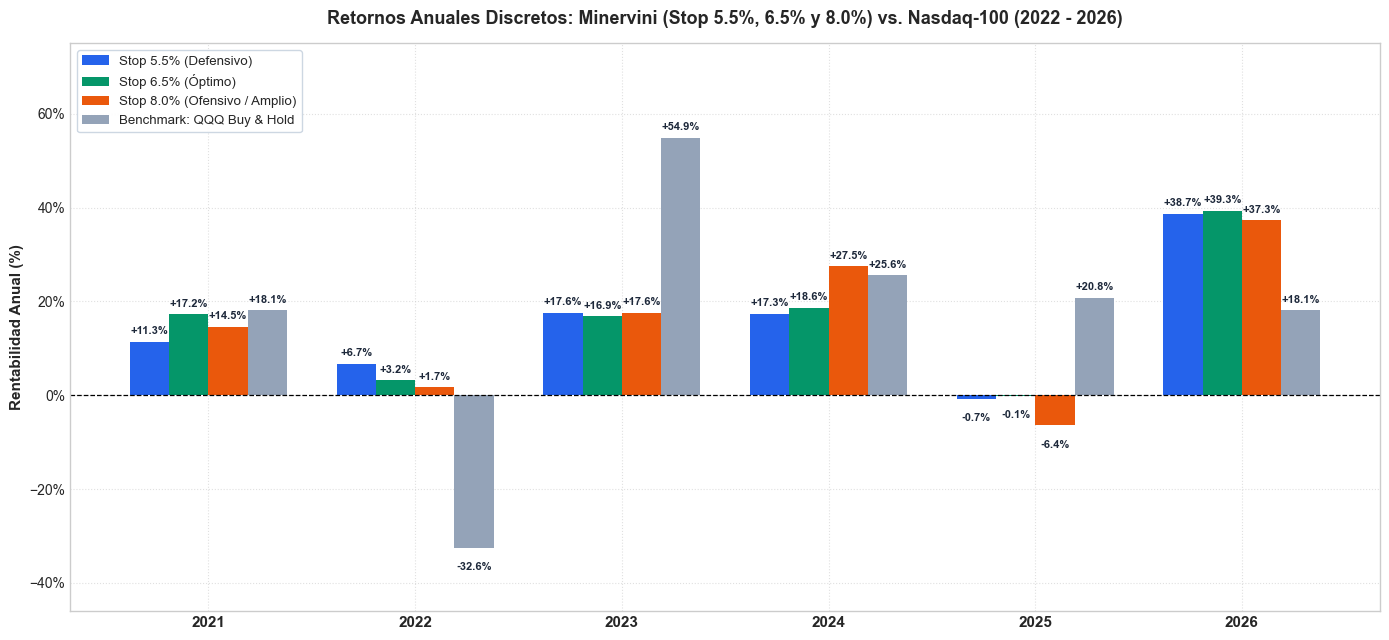

Gráfico anual exportado exitosamente como 'grafica_rendimiento_anual_tfm.png' (300 DPI).


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from motor import MinerviniBacktest

# 1. Variables base del entorno
data_base = globals().get("data_5y", globals().get("data", None))
bench_base = globals().get("benchmark_5y", globals().get("benchmark", None))
cal_base = globals().get("earnings_cal_5y", globals().get("earnings_cal", {}))

if data_base is None or bench_base is None:
    raise ValueError(
        "Faltan los datos base: ejecuta primero la celda de descarga y filtrado de datos."
    )

# 2. Configuración de modelos (5.5%, 6.5% como Óptimo y 8.0%)
modelos = {
    "Stop 5.5% (Defensivo)": {"sl": 0.055, "color": "#2563EB"},  # Azul
    "Stop 6.5% (Óptimo)": {"sl": 0.065, "color": "#059669"},  # Verde Esmeralda
    "Stop 8.0% (Ofensivo)": {"sl": 0.080, "color": "#EA580C"},  # Naranja intenso
}

eq_dict = {}
tr_dict = {}

for nombre, cfg in modelos.items():
    bt = MinerviniBacktest(
        data=data_base,
        benchmark_df=bench_base,
        earnings_calendar=cal_base,
        initial_capital=100000.0,
        max_positions=5,
        commission_rate=0.0025,
        stop_loss_pct=cfg["sl"],
        exit_sma_period=25,
        vol_mult=2.0,
        dynamic_slots=True,
        dynamic_concentration=True,
        sma_buffer_days=1,  # Salida en Open t+1
        cash_yield_annual="dynamic",  # Remuneración dinámica
    )
    eq, tr = bt.run()
    eq_dict[nombre] = eq["Equity"]
    tr_dict[nombre] = tr

# Benchmark normalizado a $100,000
ref_index = list(eq_dict.values())[0].index
bench_aligned = bench_base["Close"].reindex(ref_index).ffill()
eq_bench = (bench_aligned / bench_aligned.iloc[0]) * 100000.0


# Función auxiliar de drawdown intra-anual
def calc_max_dd(series, idx):
    sub = series.loc[idx]
    dd = (sub - sub.cummax()) / sub.cummax() * 100.0
    return dd.min()


# 3. Cálculo del desglose anual (2021 - 2026)
years = sorted(list(set(ref_index.year)))
filas_retorno = []
filas_drawdown = []

for yr in years:
    idx_yr = ref_index[ref_index.year == yr]
    idx_prev = ref_index[ref_index.year < yr]

    # Benchmark anual
    v_prev_b = (
        eq_bench.loc[idx_prev].iloc[-1] if len(idx_prev) > 0 else 100000.0
    )
    v_end_b = eq_bench.loc[idx_yr].iloc[-1]
    ret_b = ((v_end_b / v_prev_b) - 1.0) * 100.0

    fila_ret = {"Año": str(yr)}
    fila_dd = {"Año": str(yr)}
    alfas = {}

    for nombre in modelos:
        series = eq_dict[nombre]
        v_prev = (
            series.loc[idx_prev].iloc[-1] if len(idx_prev) > 0 else 100000.0
        )
        v_end = series.loc[idx_yr].iloc[-1]
        ret = ((v_end / v_prev) - 1.0) * 100.0

        label_base = nombre.split(" (")[0]  # 'Stop X.X%'
        pct_label = label_base.replace("Stop ", "")  # 'X.X%'

        fila_ret[f"{label_base} (%)"] = round(ret, 2)
        alfas[f"Alfa {pct_label} (%)"] = round(ret - ret_b, 2)
        fila_dd[f"DD Intra {pct_label} (%)"] = round(
            calc_max_dd(series, idx_yr), 2
        )

    fila_ret["QQQ Buy & Hold (%)"] = round(ret_b, 2)
    fila_ret.update(alfas)
    fila_dd["DD Intra QQQ (%)"] = round(calc_max_dd(eq_bench, idx_yr), 2)

    filas_retorno.append(fila_ret)
    filas_drawdown.append(fila_dd)

df_anual = pd.DataFrame(filas_retorno).set_index("Año")
df_dd_anual = pd.DataFrame(filas_drawdown).set_index("Año")

print("=== TABLA 1: RENTABILIDAD Y ALFA ANUAL (2021 - 2026) ===")
display(df_anual)

print("\n=== TABLA 2: DRAWDOWN MÁXIMO INTRA-ANUAL ===")
display(df_dd_anual)

# ----------------------------------------------------
# 4. GRÁFICO DE BARRAS AGRUPADAS (300 DPI)
# ----------------------------------------------------
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
fig, ax = plt.subplots(figsize=(14, 6.5))

x = np.arange(len(df_anual.index))
width = 0.19

rects1 = ax.bar(
    x - 1.5 * width,
    df_anual["Stop 5.5% (%)"],
    width,
    label="Stop 5.5% (Defensivo)",
    color=modelos["Stop 5.5% (Defensivo)"]["color"],
)
rects2 = ax.bar(
    x - 0.5 * width,
    df_anual["Stop 6.5% (%)"],
    width,
    label="Stop 6.5% (Óptimo)",
    color=modelos["Stop 6.5% (Óptimo)"]["color"],
)
rects3 = ax.bar(
    x + 0.5 * width,
    df_anual["Stop 8.0% (%)"],
    width,
    label="Stop 8.0% (Ofensivo / Amplio)",
    color=modelos["Stop 8.0% (Ofensivo)"]["color"],
)
rects4 = ax.bar(
    x + 1.5 * width,
    df_anual["QQQ Buy & Hold (%)"],
    width,
    label="Benchmark: QQQ Buy & Hold",
    color="#94A3B8",
)


def etiquetar_barras(rects):
    for rect in rects:
        h = rect.get_height()
        va = "bottom" if h >= 0 else "top"
        y_pos = h + (1.2 if h >= 0 else -3.0)
        ax.annotate(
            f"{h:+.1f}%",
            xy=(rect.get_x() + rect.get_width() / 2, y_pos),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=8.0,
            fontweight="bold",
            color="#1E293B",
        )


etiquetar_barras(rects1)
etiquetar_barras(rects2)
etiquetar_barras(rects3)
etiquetar_barras(rects4)

ax.set_title(
    "Retornos Anuales Discretos: Minervini (Stop 5.5%, 6.5% y 8.0%) vs."
    " Nasdaq-100 (2022 - 2026)",
    fontsize=13,
    fontweight="bold",
    pad=14,
)
ax.set_ylabel("Rentabilidad Anual (%)", fontsize=11, fontweight="semibold")
ax.set_xticks(x)
ax.set_xticklabels(df_anual.index, fontsize=11, fontweight="semibold")
ax.axhline(0, color="black", lw=0.9, linestyle="--")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

y_min = min(df_anual.filter(like="%").min().min() - 8, -40)
y_max = max(df_anual.filter(like="%").max().max() + 10, 75)
ax.set_ylim(y_min, y_max)

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#CBD5E1",
    framealpha=0.95,
    fontsize=9.5,
)
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("grafica_rendimiento_anual_tfm.png", dpi=300, bbox_inches="tight")
plt.show()

print(
    "Gráfico anual exportado exitosamente como"
    " 'grafica_rendimiento_anual_tfm.png' (300 DPI)."
)

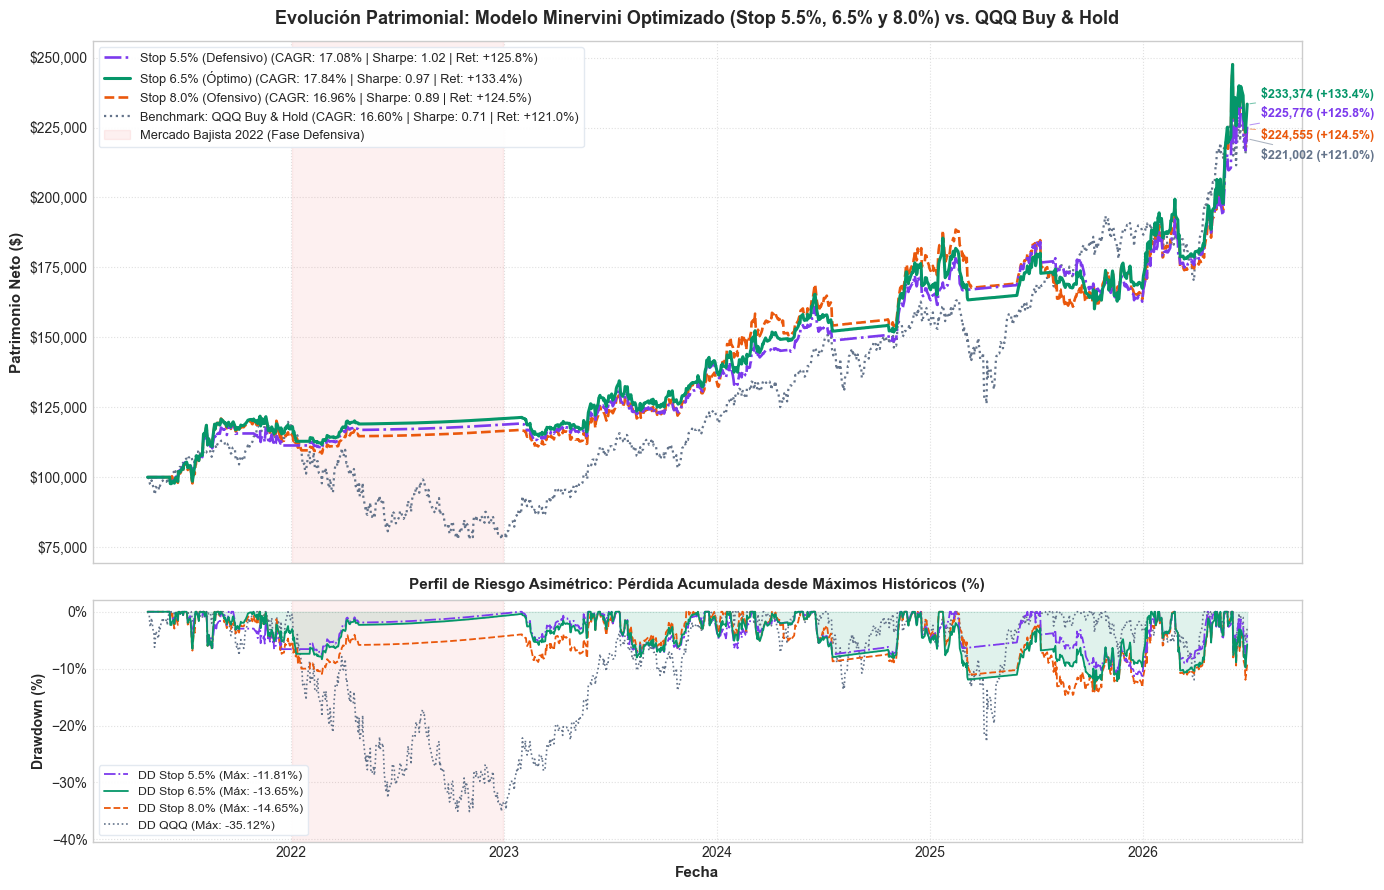

Gráfica patrimonial exportada exitosamente como 'grafica_patrimonial_riesgo_tfm.png' (300 DPI).


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from evaluacion import calculate_metrics
from motor import MinerviniBacktest

# 1. Asegurar la presencia de los tres modelos en eq_dict y tr_dict
if "eq_dict" not in locals():
    eq_dict = {}
    tr_dict = {}

modelos_a_graficar = {
    "Stop 5.5% (Defensivo)": {
        "sl": 0.055,
        "color": "#7C3AED",
        "lw": 1.9,
        "ls": "-.",
        "zorder": 4,
    },  # Púrpura
    "Stop 6.5% (Óptimo)": {
        "sl": 0.065,
        "color": "#059669",
        "lw": 2.2,
        "ls": "-",
        "zorder": 6,
    },  # Verde Esmeralda
    "Stop 8.0% (Ofensivo)": {
        "sl": 0.080,
        "color": "#EA580C",
        "lw": 1.9,
        "ls": "--",
        "zorder": 3.5,
    },  # Naranja / Ámbar
}

for nombre, cfg in modelos_a_graficar.items():
    if nombre not in eq_dict or nombre not in tr_dict:
        bt = MinerviniBacktest(
            data=data_base,
            benchmark_df=bench_base,
            earnings_calendar=cal_base,
            initial_capital=100000.0,
            max_positions=5,
            commission_rate=0.0025,
            stop_loss_pct=cfg["sl"],
            exit_sma_period=25,
            vol_mult=2.0,
            dynamic_slots=True,
            dynamic_concentration=True,
            sma_buffer_days=1,
            cash_yield_annual="dynamic",
        )
        eq, tr = bt.run()
        eq_dict[nombre] = eq["Equity"]
        tr_dict[nombre] = tr

# Benchmark alineado y normalizado
ref_idx = list(eq_dict.values())[0].index
bench_aligned = bench_base["Close"].loc[ref_idx]
eq_bench = (bench_aligned / bench_aligned.iloc[0]) * 100000.0

# 2. Métricas y Drawdowns
metricas = {
    k: calculate_metrics(
        pd.DataFrame({"Equity": eq_dict[k]}), tr_dict[k], bench_base
    )
    for k in modelos_a_graficar
}
metricas_b = calculate_metrics(
    pd.DataFrame({"Equity": eq_bench}), pd.DataFrame(), bench_base
)

dds = {
    k: (eq_dict[k] - eq_dict[k].cummax()) / eq_dict[k].cummax() * 100.0
    for k in modelos_a_graficar
}
dd_b = (eq_bench - eq_bench.cummax()) / eq_bench.cummax() * 100.0

# ----------------------------------------------------
# 3. FIGURA DE DOBLE PANEL (300 DPI)
# ----------------------------------------------------
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2.6, 1.2]}
)

# --- PANEL SUPERIOR: EVOLUCIÓN DEL PATRIMONIO NETO ---
for nombre, cfg in modelos_a_graficar.items():
    m = metricas[nombre]
    ax1.plot(
        eq_dict[nombre].index,
        eq_dict[nombre],
        label=f"{nombre} (CAGR: {m['CAGR Anualizado (%)']:.2f}% | Sharpe: {m['Ratio de Sharpe']:.2f} | Ret: +{m['Retorno Total (%)']:.1f}%)",
        color=cfg["color"],
        lw=cfg["lw"],
        linestyle=cfg["ls"],
        zorder=cfg["zorder"],
    )

ax1.plot(
    eq_bench.index,
    eq_bench,
    label=f"Benchmark: QQQ Buy & Hold (CAGR: {metricas_b['CAGR Anualizado (%)']:.2f}% | Sharpe: {metricas_b['Ratio de Sharpe']:.2f} | Ret: +{metricas_b['Retorno Total (%)']:.1f}%)",
    color="#64748B",
    lw=1.6,
    linestyle=":",
    zorder=2,
)

# Sombreado defensivo 2022
ax1.axvspan(
    pd.to_datetime("2022-01-03"),
    pd.to_datetime("2022-12-30"),
    color="#EF4444",
    alpha=0.08,
    label="Mercado Bajista 2022 (Fase Defensiva)",
)

# -------------------------------------------------------------------------
# ANOTACIONES FINALES DINÁMICAS (ANTI-COLISIÓN)
# -------------------------------------------------------------------------
items_anotacion = []
for nombre, cfg in modelos_a_graficar.items():
    val = eq_dict[nombre].iloc[-1]
    ret = metricas[nombre]["Retorno Total (%)"]
    items_anotacion.append(
        {"texto": f"${val:,.0f} (+{ret:.1f}%)", "val": val, "color": cfg["color"]}
    )

items_anotacion.append(
    {
        "texto": (
            f"${eq_bench.iloc[-1]:,.0f}"
            f" (+{metricas_b['Retorno Total (%)']:.1f}%)"
        ),
        "val": eq_bench.iloc[-1],
        "color": "#64748B",
    }
)

# Ordenar de mayor a menor valor final
items_anotacion.sort(key=lambda x: x["val"], reverse=True)

# Calcular altura de ax1 en puntos tipográficos para calibrar el espaciado
h_ax1_pt = 9.0 * (2.6 / (2.6 + 1.2)) * 72.0
y_min, y_max = ax1.get_ylim()

# Separación mínima de 16 pt convertida a unidades patrimoniales ($)
min_gap_pt = 16.0
min_gap_data = (min_gap_pt / h_ax1_pt) * (y_max - y_min)

# Algoritmo de relajación simétrica para evitar solapamientos
y_posiciones = [item["val"] for item in items_anotacion]
for _ in range(50):
    for i in range(len(y_posiciones) - 1):
        gap = y_posiciones[i] - y_posiciones[i + 1]
        if gap < min_gap_data:
            ajuste = (min_gap_data - gap) / 2.0
            y_posiciones[i] += ajuste
            y_posiciones[i + 1] -= ajuste

# Renderizado con micro-conectores en las etiquetas reubicadas
for item, y_adj in zip(items_anotacion, y_posiciones):
    offset_y_pt = ((y_adj - item["val"]) / (y_max - y_min)) * h_ax1_pt
    arrow = (
        dict(arrowstyle="-", color=item["color"], lw=0.75, alpha=0.55)
        if abs(offset_y_pt) > 2.0
        else None
    )

    ax1.annotate(
        item["texto"],
        xy=(ref_idx[-1], item["val"]),
        xytext=(10, offset_y_pt),
        textcoords="offset points",
        fontweight="bold",
        color=item["color"],
        fontsize=9.0,
        va="center",
        arrowprops=arrow,
    )

ax1.set_title(
    "Evolución Patrimonial: Modelo Minervini Optimizado (Stop 5.5%, 6.5% y"
    " 8.0%) vs. QQQ Buy & Hold",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax1.set_ylabel("Patrimonio Neto ($)", fontsize=11, fontweight="semibold")
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax1.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#E2E8F0",
    framealpha=0.95,
    fontsize=9.2,
)
ax1.grid(True, linestyle=":", alpha=0.6)

# --- PANEL INFERIOR: PERFIL DE DRAWDOWN SUBACUÁTICO (%) ---
for nombre, cfg in modelos_a_graficar.items():
    m = metricas[nombre]
    ax2.plot(
        dds[nombre].index,
        dds[nombre],
        label=(
            f"DD {nombre.split()[0]} {nombre.split()[1]} (Máx:"
            f" {m['Máximo Drawdown (%)']:.2f}%)"
        ),
        color=cfg["color"],
        lw=1.3,
        linestyle=cfg["ls"],
        zorder=cfg["zorder"],
    )

peor_dd = min(
    [m["Máximo Drawdown (%)"] for m in metricas.values()]
    + [metricas_b["Máximo Drawdown (%)"]]
)

# Sombreado bajo la curva del modelo óptimo (6.5%)
ax2.fill_between(
    dds["Stop 6.5% (Óptimo)"].index,
    dds["Stop 6.5% (Óptimo)"],
    0,
    color=modelos_a_graficar["Stop 6.5% (Óptimo)"]["color"],
    alpha=0.12,
    zorder=1,
)

ax2.plot(
    dd_b.index,
    dd_b,
    label=f"DD QQQ (Máx: {metricas_b['Máximo Drawdown (%)']:.2f}%)",
    color="#64748B",
    lw=1.2,
    linestyle=":",
    zorder=2,
)
ax2.axvspan(
    pd.to_datetime("2022-01-03"),
    pd.to_datetime("2022-12-30"),
    color="#EF4444",
    alpha=0.08,
)

ax2.set_title(
    "Perfil de Riesgo Asimétrico: Pérdida Acumulada desde Máximos Históricos"
    " (%)",
    fontsize=11,
    fontweight="bold",
    pad=8,
)
ax2.set_ylabel("Drawdown (%)", fontsize=10, fontweight="semibold")
ax2.set_xlabel("Fecha", fontsize=11, fontweight="semibold")
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))
ax2.set_ylim(peor_dd * 1.15, 2.0)
ax2.legend(
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="#E2E8F0",
    framealpha=0.95,
    fontsize=8.8,
)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("grafica_patrimonial_riesgo_tfm.png", dpi=300, bbox_inches="tight")
plt.show()

print(
    "Gráfica patrimonial exportada exitosamente como"
    " 'grafica_patrimonial_riesgo_tfm.png' (300 DPI)."
)

In [4]:
import pandas as pd
from evaluacion import calculate_metrics
from motor import MinerviniBacktest

# 1. Configuración de sensibilidad completa y ordenada (de 5.0% a 8.0%)
stops_config = {
    "Stop 5.0%": 0.050,
    "Stop 5.5%": 0.055,
    "Stop 6.0%": 0.060,
    "Stop 6.5%": 0.065,
    "Stop 7.0%": 0.070,
    "Stop 7.5%": 0.075,
    "Stop 8.0%": 0.080,
}

if "eq_dict" not in locals():
    eq_dict = {}
    tr_dict = {}

metrics_sensibilidad = {}
benchmark_metrics_raw = None

# 2. Ejecución iterativa y cálculo de métricas
for label, sl_pct in stops_config.items():
    # Buscar si ya existe la curva en eq_dict (exacta o por prefijo, ej. 'Stop 6.5% (Óptimo)')
    matching_key = next((k for k in eq_dict if k == label or k.startswith(label)), None)
    
    if matching_key is None:
        # Ejecutar backtest si el nivel de stop no está precargado
        bt = MinerviniBacktest(
            data=data_base,
            benchmark_df=bench_base,
            earnings_calendar=cal_base,
            initial_capital=100000.0,
            max_positions=5,
            commission_rate=0.0025,
            stop_loss_pct=sl_pct,
            exit_sma_period=25,
            vol_mult=2.0,
            dynamic_slots=True,
            dynamic_concentration=True,
            sma_buffer_days=1,
            cash_yield_annual="dynamic",
        )
        eq, tr = bt.run()
        eq_dict[label] = eq["Equity"]
        tr_dict[label] = tr
        matching_key = label

    equity_df = pd.DataFrame({"Equity": eq_dict[matching_key]})
    trades_df = tr_dict[matching_key]
    m = calculate_metrics(equity_df, trades_df, benchmark_df=bench_base)
    metrics_sensibilidad[label] = m

    # Extraer métricas globales del Benchmark (QQQ) en la primera pasada
    if benchmark_metrics_raw is None:

        # 1. Alinear serie de precios del benchmark con las fechas de la cartera
        bench_close = bench_base['Close'].reindex(equity_df.index).ffill()
        bench_daily_ret = bench_close.pct_change().dropna()
        
        # 2. Tasa libre de riesgo diaria (misma base del 2% que en evaluacion.py)
        rf_daily = (1.0 + 0.02) ** (1.0 / 252.0) - 1.0
        bench_excess_ret = bench_daily_ret - rf_daily
        
        bench_sharpe = (
            np.sqrt(252.0) * (bench_excess_ret.mean() / bench_daily_ret.std())
            if bench_daily_ret.std() > 1e-8 else 0.0
        )

        benchmark_metrics_raw = {
            "Retorno Total (%)": m.get("Benchmark Retorno (%)", "-"),
            "CAGR Anualizado (%)": m.get("Benchmark CAGR (%)", "-"),
            "Máximo Drawdown (%)": m.get("Benchmark Máx DD (%)", "-"),
            "Ratio de Sharpe": round(bench_sharpe, 2),
            "Ratio de Calmar": (
                round(m.get("Benchmark CAGR (%)", 0) / abs(m.get("Benchmark Máx DD (%)", 1)), 2)
                if m.get("Benchmark Máx DD (%)", 0) != 0
                else "-"
            ),
            "Win Rate (%)": "-",
            "Win Rate Ejecuciones (%)": "-",
            "Profit Factor": "-",
            "Payoff Ratio": "-",
            "Total Operaciones": "-",
            "Total Posiciones": "-",
        }

# 3. Construcción y ordenación de la tabla comparativa global
df_comparativa = pd.DataFrame(metrics_sensibilidad)

filas_ordenadas = [
    "Retorno Total (%)",
    "CAGR Anualizado (%)",
    "Máximo Drawdown (%)",
    "Ratio de Sharpe",
    "Ratio de Calmar",
    "Win Rate (%)",
    "Win Rate Ejecuciones (%)",
    "Profit Factor",
    "Payoff Ratio",
    "Total Operaciones",
    "Total Posiciones",
]

df_comparativa = df_comparativa.loc[[f for f in filas_ordenadas if f in df_comparativa.index]]
df_comparativa["QQQ (Buy & Hold)"] = [benchmark_metrics_raw.get(f, "-") for f in df_comparativa.index]

# Formatear valores numéricos a dos decimales
df_comparativa = df_comparativa.map(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else str(x))

print("=== TABLA RESUMEN: COMPARATIVA DE ROBUSTEZ (STOPS VS QQQ) ===")
display(df_comparativa)

=== TABLA RESUMEN: COMPARATIVA DE ROBUSTEZ (STOPS VS QQQ) ===


,Stop 5.0%,Stop 5.5%,Stop 6.0%,Stop 6.5%,Stop 7.0%,Stop 7.5%,Stop 8.0%,QQQ (Buy & Hold)
Retorno Total (%),120.21,125.77,122.49,133.37,127.59,118.75,124.55,121.00
CAGR Anualizado (%),16.52,17.08,16.75,17.84,17.26,16.37,16.96,16.60
Máximo Drawdown (%),-12.05,-11.81,-14.10,-13.65,-17.64,-16.93,-14.65,-35.12
Ratio de Sharpe,1.02,1.02,0.98,0.97,0.91,0.86,0.89,0.71
Ratio de Calmar,1.37,1.45,1.19,1.31,0.98,0.97,1.16,0.47
Win Rate (%),45.59,47.76,48.48,53.03,50.77,49.18,50.00,-
Win Rate Ejecuciones (%),58.43,59.30,60.47,63.95,63.22,60.76,60.53,-
Profit Factor,2.67,2.65,2.39,2.50,2.26,2.17,2.30,-
Payoff Ratio,2.99,2.55,2.50,2.31,2.41,2.37,2.35,-
Total Operaciones,89.00,86.00,86.00,86.00,87.00,79.00,76.00,-


In [5]:
import pandas as pd

# 1. Modelos a analizar en profundidad
modelos_analisis = [
    "Stop 5.5% (Defensivo)",
    "Stop 6.5% (Óptimo)",
    "Stop 8.0% (Ofensivo)",
]

# 2. Iteración y generación de la tabla individual exacta para cada modelo
for mod in modelos_analisis:
    # Búsqueda por clave exacta o por prefijo (ej. 'Stop 5.5%') en tr_dict
    clave_dict = next(
        (
            k
            for k in tr_dict
            if k == mod or k.startswith(mod.split(" (")[0])
        ),
        None,
    )

    if clave_dict is None or tr_dict[clave_dict].empty:
        print(f"\nNo hay trades registrados para: {mod}")
        continue

    trades_s = tr_dict[clave_dict]
    resumen_lista = []

    for (ticker, entry_date), grupo in trades_s.groupby(
        ["Ticker", "Entry Date"]
    ):
        total_pnl = grupo["PnL ($)"].sum()
        razones = grupo["Reason"].tolist()

        # Categorizar el tipo de salida de la posición
        if any("TP Parcial" in r for r in razones):
            if any("Stop Loss" in r or "Breakeven" in r for r in razones):
                tipo_salida = "Parcial (+18%) + Salto a Breakeven/Stop"
            elif any("Cruce SMA" in r for r in razones):
                tipo_salida = "Parcial (+18%) + Salto por Tendencia (SMA)"
            else:
                tipo_salida = "Parcial (+18%) + Cierre de Fin/Resto"
        else:
            if any("Stop Loss" in r for r in razones):
                tipo_salida = "Stop Loss Directo (Sin TP)"
            elif any("Breakeven" in r for r in razones):
                tipo_salida = "Breakeven Directo"
            elif any("Cruce SMA" in r for r in razones):
                tipo_salida = "Cruce de Tendencia (SMA) Directo"
            else:
                tipo_salida = "Cierre por Fin de Backtest"

        resumen_lista.append({"Tipo de Ciclo": tipo_salida, "PnL": total_pnl})

    df_res = pd.DataFrame(resumen_lista)

    # Agrupar para obtener conteo y rentabilidad acumulada por categoría de salida
    summary_table = (
        df_res.groupby("Tipo de Ciclo")
        .agg(Total_Posiciones=("PnL", "count"), PnL_Acumulado=("PnL", "sum"))
        .reset_index()
    )

    summary_table["% del Total"] = (
        summary_table["Total_Posiciones"]
        / summary_table["Total_Posiciones"].sum()
        * 100
    ).round(2)
    summary_table["PnL_Acumulado"] = summary_table["PnL_Acumulado"].round(2)

    # Ordenar por volumen de posiciones descendente
    summary_table = summary_table.sort_values(
        by="Total_Posiciones", ascending=False
    ).reset_index(drop=True)

    print(
        f"\n=== RESUMEN EJECUTIVO DE CICLOS DE POSICIÓN ({mod.upper()}) ==="
    )
    display(summary_table)


=== RESUMEN EJECUTIVO DE CICLOS DE POSICIÓN (STOP 5.5% (DEFENSIVO)) ===


,Tipo de Ciclo,Total_Posiciones,PnL_Acumulado,% del Total
0,Stop Loss Directo (Sin TP),27,-66278.32,40.30
1,Parcial (+18%) + Salto por Tendencia (SMA),18,106150.27,26.87
2,Cruce de Tendencia (SMA) Directo,12,26401.87,17.91
3,Breakeven Directo,8,-387.43,11.94
4,Cierre por Fin de Backtest,1,5478.76,1.49
5,Parcial (+18%) + Cierre de Fin/Resto,1,38495.28,1.49



=== RESUMEN EJECUTIVO DE CICLOS DE POSICIÓN (STOP 6.5% (ÓPTIMO)) ===


,Tipo de Ciclo,Total_Posiciones,PnL_Acumulado,% del Total
0,Stop Loss Directo (Sin TP),29,-77807.09,43.94
1,Parcial (+18%) + Salto por Tendencia (SMA),19,117023.96,28.79
2,Cruce de Tendencia (SMA) Directo,14,34993.65,21.21
3,Breakeven Directo,2,-1224.54,3.03
4,Cierre por Fin de Backtest,1,5624.22,1.52
5,Parcial (+18%) + Cierre de Fin/Resto,1,39728.42,1.52



=== RESUMEN EJECUTIVO DE CICLOS DE POSICIÓN (STOP 8.0% (OFENSIVO)) ===


,Tipo de Ciclo,Total_Posiciones,PnL_Acumulado,% del Total
0,Stop Loss Directo (Sin TP),28,-84063.59,46.67
1,Parcial (+18%) + Salto por Tendencia (SMA),15,101365.70,25.00
2,Cruce de Tendencia (SMA) Directo,12,51377.74,20.00
3,Cierre por Fin de Backtest,3,3260.66,5.00
4,Breakeven Directo,1,-760.51,1.67
5,Parcial (+18%) + Cierre de Fin/Resto,1,40043.11,1.67


Descargando 15 activos históricos para reconstruir el universo con sesgo...


2026-09-17 00:32:51,923 - INFO - Descarga finalizada: 15 admitidos, 0 descartados.


Universo Con Sesgo: 96 activos.
Universo Sin Sesgo: 81 activos.

Calculando Trend Template y matrices RS transversales...
Simulando Universo CON Sesgo (96 activos)...
Simulando Universo SIN Sesgo (81 activos)...

=== COMPARATIVA CUANTITATIVA DEL SESGO DE ANTICIPACIÓN ===


,Con Sesgo (Original),Sin Sesgo (Depurado),Impacto del Sesgo
Métrica,,,
Capital Final ($),"$395,215.84","$233,373.67","$161,842.17"
Retorno Total (%),295.21%,133.37%,+161.84%
CAGR (%),30.49%,17.84%,+12.65%
Máximo Drawdown (%),-15.90%,-13.65%,-2.25%
Ratio de Sharpe,1.37,0.97,+0.40
Ratio de Calmar,1.92,1.31,+0.61
Total Operaciones,110,86,24


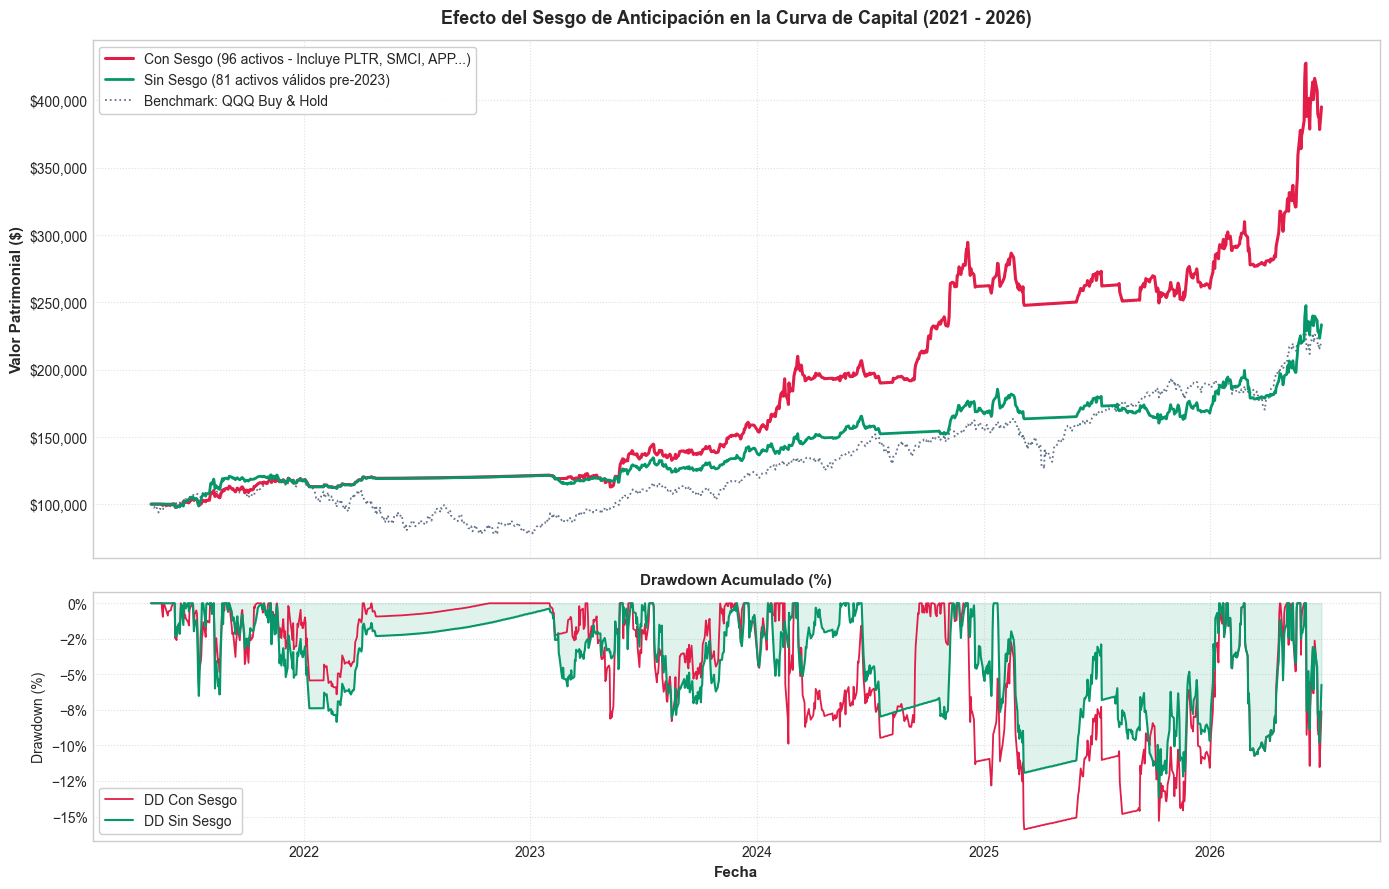

Gráfico exportado como 'comparativa_sesgo_anticipacion_tfm.png'.


In [6]:
# =========================================================================
# ANÁLISIS DE IMPACTO DEL SESGO DE ANTICIPACIÓN (LOOK-AHEAD BIAS)
# Comparativa real: 96 activos (Con Sesgo) vs. 81 activos (Sin Sesgo)
# =========================================================================
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import yfinance as yf

from datos_filtrado import calculate_trend_template, get_historical_data
from evaluacion import calculate_metrics
from motor import MinerviniBacktest

# 1. Recuperar variables base
if "raw_data" not in globals() or "benchmark_5y" not in globals():
    raise ValueError("Ejecuta primero la Celda 1 para disponer del benchmark y fechas.")

bench_base = globals()["benchmark_5y"]
cal_base = globals().get("earnings_cal_5y", {})
start_dt = globals().get("start_date", (pd.Timestamp.now() - pd.DateOffset(years=6, months=2)).strftime("%Y-%m-%d"))
end_dt = globals().get("end_date", pd.Timestamp.now().strftime("%Y-%m-%d"))

# 2. Lista de los 15 valores incorporados en 2023-2024
TICKERS_EXCLUIDOS = [
    "ARM", "SMCI", "PLTR", "APP", "AXON", "DASH", "MDB",
    "CCEP", "ROP", "TTWO", "TTD", "ON", "LIN", "GEHC", "ANET"
]

# 3. Asegurar que disponemos de ambos universos en memoria
raw_actual = globals()["raw_data"]
missing_tickers = [t for t in TICKERS_EXCLUIDOS if t not in raw_actual]

if missing_tickers:
    print(f"Descargando {len(missing_tickers)} activos históricos para reconstruir el universo con sesgo...")
    extra_data, _ = get_historical_data(missing_tickers, start_date=start_dt, end_date=end_dt)
    raw_con_sesgo = {**raw_actual, **extra_data}
else:
    raw_con_sesgo = raw_actual.copy()

raw_sin_sesgo = {t: df.copy() for t, df in raw_con_sesgo.items() if t not in TICKERS_EXCLUIDOS}

print(f"Universo Con Sesgo: {len(raw_con_sesgo)} activos.")
print(f"Universo Sin Sesgo: {len(raw_sin_sesgo)} activos.")

# 4. Cálculo independiente del Trend Template (matrices RS separadas)
print("\nCalculando Trend Template y matrices RS transversales...")
data_con = calculate_trend_template(raw_con_sesgo, bench_base)
data_sin = calculate_trend_template(raw_sin_sesgo, bench_base)

# 5. Ejecución de los dos backtests (Modelo Óptimo: Stop 6.5%)
cfg_modelo = {
    "initial_capital": 100000.0,
    "max_positions": 5,
    "commission_rate": 0.0025,
    "stop_loss_pct": 0.065,
    "exit_sma_period": 25,
    "vol_mult": 2.0,
    "dynamic_slots": True,
    "dynamic_concentration": True,
    "sma_buffer_days": 1,
    "cash_yield_annual": "dynamic"
}

print("Simulando Universo CON Sesgo (96 activos)...")
bt_con = MinerviniBacktest(data=data_con, benchmark_df=bench_base, earnings_calendar=cal_base, **cfg_modelo)
eq_con, tr_con = bt_con.run()

print("Simulando Universo SIN Sesgo (81 activos)...")
bt_sin = MinerviniBacktest(data=data_sin, benchmark_df=bench_base, earnings_calendar=cal_base, **cfg_modelo)
eq_sin, tr_sin = bt_sin.run()

# 6. Benchmark QQQ normalizado
ref_idx = eq_con.index
bench_aligned = bench_base["Close"].reindex(ref_idx).ffill()
eq_bench = (bench_aligned / bench_aligned.iloc[0]) * 100000.0

# 7. Tabla de métricas comparadas
met_con = calculate_metrics(eq_con, tr_con, bench_base)
met_sin = calculate_metrics(eq_sin, tr_sin, bench_base)

df_comp = pd.DataFrame([
    {
        "Métrica": "Capital Final ($)",
        "Con Sesgo (Original)": f"${eq_con['Equity'].iloc[-1]:,.2f}",
        "Sin Sesgo (Depurado)": f"${eq_sin['Equity'].iloc[-1]:,.2f}",
        "Impacto del Sesgo": f"${eq_con['Equity'].iloc[-1] - eq_sin['Equity'].iloc[-1]:,.2f}"
    },
    {
        "Métrica": "Retorno Total (%)",
        "Con Sesgo (Original)": f"{met_con['Retorno Total (%)']:.2f}%",
        "Sin Sesgo (Depurado)": f"{met_sin['Retorno Total (%)']:.2f}%",
        "Impacto del Sesgo": f"{met_con['Retorno Total (%)'] - met_sin['Retorno Total (%)']:+.2f}%"
    },
    {
        "Métrica": "CAGR (%)",
        "Con Sesgo (Original)": f"{met_con['CAGR Anualizado (%)']:.2f}%",
        "Sin Sesgo (Depurado)": f"{met_sin['CAGR Anualizado (%)']:.2f}%",
        "Impacto del Sesgo": f"{met_con['CAGR Anualizado (%)'] - met_sin['CAGR Anualizado (%)']:+.2f}%"
    },
    {
        "Métrica": "Máximo Drawdown (%)",
        "Con Sesgo (Original)": f"{met_con['Máximo Drawdown (%)']:.2f}%",
        "Sin Sesgo (Depurado)": f"{met_sin['Máximo Drawdown (%)']:.2f}%",
        "Impacto del Sesgo": f"{met_con['Máximo Drawdown (%)'] - met_sin['Máximo Drawdown (%)']:+.2f}%"
    },
    {
        "Métrica": "Ratio de Sharpe",
        "Con Sesgo (Original)": f"{met_con['Ratio de Sharpe']:.2f}",
        "Sin Sesgo (Depurado)": f"{met_sin['Ratio de Sharpe']:.2f}",
        "Impacto del Sesgo": f"{met_con['Ratio de Sharpe'] - met_sin['Ratio de Sharpe']:+.2f}"
    },
    {
        "Métrica": "Ratio de Calmar",
        "Con Sesgo (Original)": f"{met_con['Ratio de Calmar']:.2f}",
        "Sin Sesgo (Depurado)": f"{met_sin['Ratio de Calmar']:.2f}",
        "Impacto del Sesgo": f"{met_con['Ratio de Calmar'] - met_sin['Ratio de Calmar']:+.2f}"
    },
    {
        "Métrica": "Total Operaciones",
        "Con Sesgo (Original)": f"{met_con['Total Operaciones']}",
        "Sin Sesgo (Depurado)": f"{met_sin['Total Operaciones']}",
        "Impacto del Sesgo": f"{met_con['Total Operaciones'] - met_sin['Total Operaciones']}"
    }
]).set_index("Métrica")

print("\n=== COMPARATIVA CUANTITATIVA DEL SESGO DE ANTICIPACIÓN ===")
display(df_comp)

# 8. Gráfico comparativo dual
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [2.5, 1.2]}, sharex=True)

# Curva de Equity
ax1.plot(eq_con.index, eq_con["Equity"], label="Con Sesgo (96 activos - Incluye PLTR, SMCI, APP...)", color="#E11D48", lw=2.2, zorder=3)
ax1.plot(eq_sin.index, eq_sin["Equity"], label="Sin Sesgo (81 activos válidos pre-2023)", color="#059669", lw=2.0, zorder=4)
ax1.plot(eq_bench.index, eq_bench, label="Benchmark: QQQ Buy & Hold", color="#64748B", lw=1.3, linestyle=":", zorder=2)

ax1.set_title("Efecto del Sesgo de Anticipación en la Curva de Capital (2021 - 2026)", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Valor Patrimonial ($)", fontsize=11, fontweight="semibold")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"${int(y):,}"))
ax1.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.95)
ax1.grid(True, linestyle=":", alpha=0.6)

# Curva de Drawdown
dd_con = (eq_con["Equity"] - eq_con["Equity"].cummax()) / eq_con["Equity"].cummax() * 100.0
dd_sin = (eq_sin["Equity"] - eq_sin["Equity"].cummax()) / eq_sin["Equity"].cummax() * 100.0

ax2.plot(dd_con.index, dd_con, color="#E11D48", lw=1.3, label="DD Con Sesgo", zorder=3)
ax2.plot(dd_sin.index, dd_sin, color="#059669", lw=1.5, label="DD Sin Sesgo", zorder=4)
ax2.fill_between(dd_sin.index, dd_sin, 0, color="#059669", alpha=0.12)

ax2.set_title("Drawdown Acumulado (%)", fontsize=11, fontweight="semibold")
ax2.set_ylabel("Drawdown (%)", fontsize=10)
ax2.set_xlabel("Fecha", fontsize=11, fontweight="semibold")
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax2.legend(loc="lower left", frameon=True, facecolor="white", framealpha=0.95)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("comparativa_sesgo_anticipacion_tfm.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico exportado como 'comparativa_sesgo_anticipacion_tfm.png'.")

In [7]:
import pandas as pd

# Seleccionamos el modelo a auditar
modelo_auditar = "Stop 6.5% (Óptimo)"
trades = tr_dict[modelo_auditar].copy()
equity = eq_dict[modelo_auditar]

# 1. Delimitar la curva patrimonial de 2025
equity_2025 = equity.loc['2025-01-01':'2025-12-31']

# Identificar el pico patrimonial de 2025 y el mínimo posterior (suelo del Drawdown)
fecha_pico = equity_2025.idxmax()
valor_pico = equity_2025.loc[fecha_pico]

# Suelo posterior al pico
equity_post_pico = equity_2025.loc[fecha_pico:]
fecha_suelo = equity_post_pico.idxmin()
valor_suelo = equity_post_pico.loc[fecha_suelo]

caida_max_pct = ((valor_suelo / valor_pico) - 1.0) * 100.0

print(f"=== AUDITORÍA DEL DESPLOME DE 2025 ({modelo_auditar}) ===")
print(f"Pico patrimonial 2025:  {fecha_pico.strftime('%Y-%m-%d')} -> ${valor_pico:,.2f}")
print(f"Suelo de la caída 2025: {fecha_suelo.strftime('%Y-%m-%d')} -> ${valor_suelo:,.2f}")
print(f"Caída acumulada (DD):   {caida_max_pct:.2f}%\n")

# 2. Filtrar trades con fecha de salida dentro del periodo de caída (o segundo semestre de 2025)
trades['Exit Date'] = pd.to_datetime(trades['Exit Date'])
trades['Entry Date'] = pd.to_datetime(trades['Entry Date'])

# Trades cerrados entre el pico y el suelo
trades_caida = trades[(trades['Exit Date'] >= fecha_pico) & (trades['Exit Date'] <= fecha_suelo)].sort_values('Exit Date')

print(f"--- Operaciones cerradas entre el pico y el suelo ({len(trades_caida)} trades) ---")
cols_mostrar = ['Ticker', 'Entry Date', 'Exit Date', 'Entry Price', 'Exit Price', 'Return (%)', 'PnL ($)', 'Reason']
display(trades_caida[cols_mostrar])

# 3. Desglose de motivos de salida en la caída
print("\n--- Motivos de salida en el periodo crítico ---")
display(trades_caida['Reason'].value_counts().to_frame(name='Total Salidas'))

# 4. Todos los trades cerrados en el segundo semestre de 2025 (visión global de H2)
print("\n--- Todas las operaciones cerradas en H2 2025 (2025-07-01 a 2025-12-31) ---")
trades_h2 = trades[(trades['Exit Date'] >= '2025-07-01') & (trades['Exit Date'] <= '2025-12-31')].sort_values('Exit Date')
display(trades_h2[cols_mostrar])

=== AUDITORÍA DEL DESPLOME DE 2025 (Stop 6.5% (Óptimo)) ===
Pico patrimonial 2025:  2025-01-23 -> $185,490.20
Suelo de la caída 2025: 2025-10-10 -> $160,170.83
Caída acumulada (DD):   -13.65%

--- Operaciones cerradas entre el pico y el suelo (10 trades) ---


,Ticker,Entry Date,Exit Date,Entry Price,Exit Price,Return (%),PnL ($),Reason
52,CEG,2025-01-13,2025-01-27,294.53,289.55,-1.69,-1224.54,Breakeven Neto (Gap Down)
53,TEAM,2025-02-03,2025-02-24,299.11,279.67,-6.50,-2381.36,Stop Loss
54,ISRG,2024-10-21,2025-02-26,519.04,570.85,9.98,4810.36,Cruce SMA 25 (Buffer 1d)
55,NFLX,2025-01-23,2025-03-07,95.78,89.56,-6.50,-2535.17,Stop Loss
56,META,2025-01-28,2025-03-07,662.72,619.65,-6.50,-2360.43,Stop Loss
57,ZS,2025-06-02,2025-07-11,276.62,297.39,7.51,3828.33,Cruce SMA 25 (Buffer 1d)
58,CRWD,2025-06-04,2025-07-11,113.69,122.00,7.31,3807.58,Cruce SMA 25 (Buffer 1d)
59,IDXX,2025-08-05,2025-08-06,676.48,632.51,-6.50,-4015.71,Stop Loss
60,META,2025-08-01,2025-10-01,758.24,708.96,-6.50,-4024.50,Stop Loss
61,AMD,2025-10-09,2025-10-10,236.30,220.94,-6.50,-2326.87,Stop Loss



--- Motivos de salida en el periodo crítico ---


,Total Salidas
Reason,
Stop Loss,6
Cruce SMA 25 (Buffer 1d),3
Breakeven Neto (Gap Down),1



--- Todas las operaciones cerradas en H2 2025 (2025-07-01 a 2025-12-31) ---


,Ticker,Entry Date,Exit Date,Entry Price,Exit Price,Return (%),PnL ($),Reason
57,ZS,2025-06-02,2025-07-11,276.62,297.39,7.51,3828.33,Cruce SMA 25 (Buffer 1d)
58,CRWD,2025-06-04,2025-07-11,113.69,122.00,7.31,3807.58,Cruce SMA 25 (Buffer 1d)
59,IDXX,2025-08-05,2025-08-06,676.48,632.51,-6.50,-4015.71,Stop Loss
60,META,2025-08-01,2025-10-01,758.24,708.96,-6.50,-4024.50,Stop Loss
61,AMD,2025-10-09,2025-10-10,236.30,220.94,-6.50,-2326.87,Stop Loss
62,CRWD,2025-09-19,2025-11-19,124.75,128.34,2.88,810.98,Cruce SMA 25 (Buffer 1d)
63,DDOG,2025-11-07,2025-11-20,184.29,172.31,-6.50,-2329.53,Stop Loss
64,IDXX,2025-11-25,2025-12-09,751.75,702.89,-6.50,-2415.02,Stop Loss
65,AVGO,2025-09-08,2025-12-10,340.26,406.61,19.50,5287.60,TP Parcial (50% Intradía)
66,AVGO,2025-09-08,2025-12-15,340.26,359.87,5.77,1482.88,Cruce SMA 25 (Buffer 1d)


In [8]:
# =========================================================================
# TEST DE SENSIBILIDAD: TIME STOP (INACTIVIDAD) VS MODELO BASE
# =========================================================================
import copy
import pandas as pd
from evaluacion import calculate_metrics
from motor import MinerviniBacktest

# 1. Subclase que incorpora el Time Stop sin alterar motor.py permanentemente
class MinerviniBacktestTimeStop(MinerviniBacktest):
    def __init__(self, *args, time_stop_bars=None, time_stop_threshold=0.03, **kwargs):
        super().__init__(*args, **kwargs)
        self.time_stop_bars = time_stop_bars
        self.time_stop_threshold = time_stop_threshold

    def run(self):
        # Inyectar el rastreo de barras en las posiciones al ejecutar
        self.capital = self.initial_capital
        self.positions = {}
        self.trade_history = []
        self.equity_curve = []

        sma_col = f'SMA_{self.exit_sma_period}'
        if 'SMA_200' not in self.benchmark_df.columns:
            self.benchmark_df['SMA_200'] = self.benchmark_df['Close'].rolling(window=200).mean()

        for ticker, df in self.data.items():
            if sma_col not in df.columns:
                df[sma_col] = df['Close'].rolling(window=self.exit_sma_period).mean()
            if 'Resist_40' not in df.columns:
                df['Resist_40'] = df['High'].shift(1).rolling(40).max()
            if 'Vol_SMA_50' not in df.columns:
                df['Vol_SMA_50'] = df['Volume'].shift(1).rolling(50).mean()

        simulation_dates = self.benchmark_df.index[252:]
        factor_breakeven_neto = (1.0 + self.commission_rate) / (1.0 - self.commission_rate)

        # Configuración de rendimiento de tesorería dinámica
        HISTORICAL_FED_RATES = [
            ("2020-01-01", 0.0009), ("2022-03-17", 0.0033), ("2022-05-05", 0.0083),
            ("2022-06-16", 0.0158), ("2022-07-28", 0.0233), ("2022-09-22", 0.0308),
            ("2022-11-03", 0.0383), ("2022-12-15", 0.0433), ("2023-02-02", 0.0458),
            ("2023-03-23", 0.0483), ("2023-05-04", 0.0508), ("2023-07-27", 0.0533),
            ("2024-09-19", 0.0483), ("2024-11-08", 0.0458), ("2024-12-19", 0.0433),
            ("2025-06-01", 0.0385),
        ]
        sched_df = pd.DataFrame(HISTORICAL_FED_RATES, columns=['Date', 'Rate'])
        sched_df['Date'] = pd.to_datetime(sched_df['Date'])
        sim_tz = simulation_dates.tz if hasattr(simulation_dates, 'tz') else None
        if sim_tz is not None:
            sched_df['Date'] = sched_df['Date'].dt.tz_localize(sim_tz)
        sched_df = sched_df.set_index('Date')
        annual_rates = sched_df.reindex(sched_df.index.union(simulation_dates)).ffill().loc[simulation_dates]['Rate']
        daily_yield_series = (1.0 + annual_rates) ** (1.0 / 252.0) - 1.0

        pending_buys = []
        pending_exits = []

        for i, current_date in enumerate(simulation_dates):
            is_last_day = (i == len(simulation_dates) - 1)

            # 1.1 Remuneración caja
            daily_rate = min(float(daily_yield_series.loc[current_date]), 0.001)
            if self.capital > 0 and daily_rate > 0:
                self.capital += self.capital * daily_rate

            # 1.2 Ejecución ventas pendientes
            for exit_order in pending_exits:
                ticker = exit_order['ticker']
                if ticker in self.positions and current_date in self.data[ticker].index:
                    pos = self.positions[ticker]
                    open_price = float(self.data[ticker].loc[current_date, 'Open'])
                    gross_rev = pos['shares'] * open_price
                    net_rev = gross_rev * (1.0 - self.commission_rate)
                    pnl = net_rev - pos['total_cost']
                    pnl_pct = (open_price / pos['entry_price']) - 1.0

                    self.capital += net_rev
                    self.trade_history.append({
                        'Ticker': ticker,
                        'Entry Date': pos['entry_date'].strftime('%Y-%m-%d'),
                        'Exit Date': current_date.strftime('%Y-%m-%d'),
                        'Entry Price': round(pos['entry_price'], 2),
                        'Exit Price': round(open_price, 2),
                        'PnL ($)': round(pnl, 2),
                        'Return (%)': round(pnl_pct * 100, 2),
                        'Reason': exit_order['reason']
                    })
                    del self.positions[ticker]

            pending_exits = [e for e in pending_exits if e['ticker'] in self.positions]

            # 1.3 Compras pendientes
            if pending_buys and not is_last_day:
                for t, p in self.positions.items():
                    if current_date in self.data[t].index:
                        p['last_open'] = float(self.data[t].loc[current_date, 'Open'])

                portfolio_value_open = self.capital + sum(
                    p['shares'] * p['last_open'] for p in self.positions.values()
                )

                for buy_order in pending_buys:
                    current_occupied = sum(0.5 if p['partial_sold'] else 1.0 for p in self.positions.values())
                    if current_occupied >= self.max_positions:
                        break

                    ticker = buy_order['ticker']
                    if ticker in self.positions or current_date not in self.data[ticker].index:
                        continue

                    open_price = float(self.data[ticker].loc[current_date, 'Open'])
                    ref_close = buy_order.get('ref_close', open_price)
                    if self.max_chase_pct is not None and open_price > ref_close * (1.0 + self.max_chase_pct):
                        continue

                    target_size = portfolio_value_open / (3.0 if len(self.positions) <= 1 else self.max_positions)
                    allocated_cash = min(target_size, self.capital)
                    if allocated_cash < portfolio_value_open * 0.10:
                        continue

                    shares = int(allocated_cash // (open_price * (1.0 + self.commission_rate)))
                    cost = shares * open_price * (1.0 + self.commission_rate)

                    if shares > 0 and self.capital >= cost:
                        self.capital -= cost
                        self.positions[ticker] = {
                            'shares': shares,
                            'entry_price': open_price,
                            'entry_date': current_date,
                            'total_cost': cost,
                            'stop_loss': open_price * (1.0 - self.stop_loss_pct),
                            'partial_sold': False,
                            'reached_2r': False,
                            'sma_below_count': 0,
                            'bars_held': 0,          # <-- Contador de barras
                            'last_open': open_price,
                            'last_close': open_price
                        }
            pending_buys.clear()

            # 2. Intradía
            closed_intraday = []
            for ticker, pos in self.positions.items():
                if current_date not in self.data[ticker].index:
                    continue

                row_today = self.data[ticker].loc[current_date]
                high_today, low_today = float(row_today['High']), float(row_today['Low'])
                open_today, close_today = float(row_today['Open']), float(row_today['Close'])

                breakeven_trigger = pos['entry_price'] * (1.0 + (2.0 * self.stop_loss_pct))
                stop_breakeven_neto = pos['entry_price'] * factor_breakeven_neto
                tp_trigger = pos['entry_price'] * (1.0 + (self.stop_loss_pct * 3.0))

                # Gaps en Open
                if open_today <= pos['stop_loss']:
                    exit_price = open_today
                    net_rev = pos['shares'] * exit_price * (1.0 - self.commission_rate)
                    self.capital += net_rev
                    self.trade_history.append({
                        'Ticker': ticker,
                        'Entry Date': pos['entry_date'].strftime('%Y-%m-%d'),
                        'Exit Date': current_date.strftime('%Y-%m-%d'),
                        'Entry Price': round(pos['entry_price'], 2),
                        'Exit Price': round(exit_price, 2),
                        'PnL ($)': round(net_rev - pos['total_cost'], 2),
                        'Return (%)': round(((exit_price / pos['entry_price']) - 1.0) * 100, 2),
                        'Reason': 'Stop Loss (Gap Down)'
                    })
                    closed_intraday.append(ticker)
                    continue

                if open_today >= breakeven_trigger:
                    pos['reached_2r'] = True
                    pos['stop_loss'] = max(pos['stop_loss'], stop_breakeven_neto)

                if open_today >= tp_trigger and not pos['partial_sold']:
                    shares_sold = pos['shares'] // 2
                    if shares_sold > 0:
                        net_rev = shares_sold * open_today * (1.0 - self.commission_rate)
                        cost_sold = shares_sold * pos['entry_price'] * (1.0 + self.commission_rate)
                        self.capital += net_rev
                        self.trade_history.append({
                            'Ticker': ticker,
                            'Entry Date': pos['entry_date'].strftime('%Y-%m-%d'),
                            'Exit Date': current_date.strftime('%Y-%m-%d'),
                            'Entry Price': round(pos['entry_price'], 2),
                            'Exit Price': round(open_today, 2),
                            'PnL ($)': round(net_rev - cost_sold, 2),
                            'Return (%)': round(((open_today / pos['entry_price']) - 1.0) * 100, 2),
                            'Reason': 'TP Parcial (50% Gap Up)'
                        })
                        pos['shares'] -= shares_sold
                        pos['total_cost'] -= cost_sold
                        pos['partial_sold'] = True
                        pos['reached_2r'] = True
                        pos['stop_loss'] = max(pos['stop_loss'], stop_breakeven_neto)

                # Intradía normal
                hits_stop = low_today <= pos['stop_loss']
                hits_2r = high_today >= breakeven_trigger
                hits_tp = high_today >= tp_trigger and not pos['partial_sold']
                target_first = (close_today < open_today) if (hits_stop and (hits_2r or hits_tp)) else (hits_2r or hits_tp)

                if target_first and (hits_2r or hits_tp):
                    if hits_2r:
                        pos['reached_2r'] = True
                        pos['stop_loss'] = max(pos['stop_loss'], stop_breakeven_neto)
                    if hits_tp:
                        shares_sold = pos['shares'] // 2
                        if shares_sold > 0:
                            net_rev = shares_sold * tp_trigger * (1.0 - self.commission_rate)
                            cost_sold = shares_sold * pos['entry_price'] * (1.0 + self.commission_rate)
                            self.capital += net_rev
                            self.trade_history.append({
                                'Ticker': ticker,
                                'Entry Date': pos['entry_date'].strftime('%Y-%m-%d'),
                                'Exit Date': current_date.strftime('%Y-%m-%d'),
                                'Entry Price': round(pos['entry_price'], 2),
                                'Exit Price': round(tp_trigger, 2),
                                'PnL ($)': round(net_rev - cost_sold, 2),
                                'Return (%)': round(((tp_trigger / pos['entry_price']) - 1.0) * 100, 2),
                                'Reason': 'TP Parcial (50% Intradía)'
                            })
                            pos['shares'] -= shares_sold
                            pos['total_cost'] -= cost_sold
                            pos['partial_sold'] = True
                            pos['reached_2r'] = True
                            pos['stop_loss'] = max(pos['stop_loss'], stop_breakeven_neto)

                if hits_stop:
                    exit_price = pos['stop_loss']
                    net_rev = pos['shares'] * exit_price * (1.0 - self.commission_rate)
                    self.capital += net_rev
                    self.trade_history.append({
                        'Ticker': ticker,
                        'Entry Date': pos['entry_date'].strftime('%Y-%m-%d'),
                        'Exit Date': current_date.strftime('%Y-%m-%d'),
                        'Entry Price': round(pos['entry_price'], 2),
                        'Exit Price': round(exit_price, 2),
                        'PnL ($)': round(net_rev - pos['total_cost'], 2),
                        'Return (%)': round(((exit_price / pos['entry_price']) - 1.0) * 100, 2),
                        'Reason': 'Breakeven (+2R)' if pos['stop_loss'] >= pos['entry_price'] else 'Stop Loss'
                    })
                    closed_intraday.append(ticker)

            for t in closed_intraday:
                del self.positions[t]

            # 3. Cierre y Time Stop
            for ticker, pos in self.positions.items():
                if current_date in self.data[ticker].index:
                    pos['last_close'] = float(self.data[ticker].loc[current_date, 'Close'])

            closed_at_close = []
            for ticker, pos in self.positions.items():
                if is_last_day:
                    close_p = pos['last_close']
                    net_rev = pos['shares'] * close_p * (1.0 - self.commission_rate)
                    self.capital += net_rev
                    self.trade_history.append({
                        'Ticker': ticker,
                        'Entry Date': pos['entry_date'].strftime('%Y-%m-%d'),
                        'Exit Date': current_date.strftime('%Y-%m-%d'),
                        'Entry Price': round(pos['entry_price'], 2),
                        'Exit Price': round(close_p, 2),
                        'PnL ($)': round(net_rev - pos['total_cost'], 2),
                        'Return (%)': round(((close_p / pos['entry_price']) - 1.0) * 100, 2),
                        'Reason': 'Cierre Fin Backtest'
                    })
                    closed_at_close.append(ticker)
                    continue

                if current_date not in self.data[ticker].index:
                    continue

                row_today = self.data[ticker].loc[current_date]
                close_today = float(row_today['Close'])
                sma_exit = float(row_today[sma_col])
                pos['bars_held'] += 1
                unrealized_pnl = (close_today / pos['entry_price']) - 1.0

                # A) LÓGICA DE TIME STOP
                if (self.time_stop_bars is not None and 
                    pos['bars_held'] >= self.time_stop_bars and 
                    not pos['reached_2r'] and 
                    unrealized_pnl < self.time_stop_threshold):
                    if not any(e['ticker'] == ticker for e in pending_exits):
                        pending_exits.append({
                            'ticker': ticker,
                            'reason': f'Time Stop ({pos["bars_held"]}d, PnL {unrealized_pnl*100:.1f}%)'
                        })
                    continue

                # B) Salida por SMA tras 2R
                if pos['reached_2r']:
                    if close_today < sma_exit:
                        pos['sma_below_count'] += 1
                        if pos['sma_below_count'] >= self.sma_buffer_days:
                            if not any(e['ticker'] == ticker for e in pending_exits):
                                pending_exits.append({
                                    'ticker': ticker,
                                    'reason': f'Cruce SMA {self.exit_sma_period}'
                                })
                    else:
                        pos['sma_below_count'] = 0

            for t in closed_at_close:
                del self.positions[t]

            # Mark-to-market
            pv_close = self.capital + sum(p['shares'] * p['last_close'] for p in self.positions.values())
            self.equity_curve.append({'Date': current_date, 'Equity': pv_close})

            # Detección de breakouts
            if not is_last_day:
                occupied_slots = sum(0.5 if p['partial_sold'] else 1.0 for p in self.positions.values())
                slots_to_free = sum(0.5 if self.positions[e['ticker']]['partial_sold'] else 1.0 
                                    for e in pending_exits if e['ticker'] in self.positions)
                available_slots = int(np.floor(self.max_positions - max(0.0, occupied_slots - slots_to_free)))
                mercado_favorable = float(self.benchmark_df.loc[current_date, 'Close']) > float(self.benchmark_df.loc[current_date, 'SMA_200'])

                if available_slots > 0 and mercado_favorable:
                    candidates = []
                    for ticker, df in self.data.items():
                        if ticker in self.positions or any(e['ticker'] == ticker for e in pending_exits) or current_date not in df.index:
                            continue
                        if self._has_upcoming_earnings(ticker, current_date, window_days=self.earnings_entry_buffer):
                            continue

                        row = df.loc[current_date]
                        trend_pass = row.get('Trend_Template_Pass', False)
                        if not pd.notna(trend_pass) or not bool(trend_pass):
                            continue

                        r40 = float(row['Resist_40'])
                        v50 = float(row['Vol_SMA_50'])
                        rs = float(row['RS_Ratio'])
                        h52 = float(row['High_52w'])
                        c_p = float(row['Close'])

                        if np.isnan(r40) or np.isnan(v50) or np.isnan(rs) or np.isnan(h52) or np.isnan(c_p):
                            continue

                        if c_p > r40 and float(row['Volume']) >= self.vol_mult * v50 and c_p >= (h52 * 0.85):
                            candidates.append((ticker, rs))

                    candidates.sort(key=lambda x: x[1], reverse=True)
                    for ticker, _ in candidates[:available_slots]:
                        pending_buys.append({
                            'ticker': ticker,
                            'ref_close': float(self.data[ticker].loc[current_date, 'Close'])
                        })

        return pd.DataFrame(self.equity_curve).set_index('Date'), pd.DataFrame(self.trade_history)

# =========================================================================
# 2. EJECUCIÓN COMPARATIVA (BASE vs TIME STOP 20 DÍAS vs TIME STOP 25 DÍAS)
# =========================================================================
configs = {
    "Base (Sin Time Stop)": None,
    "Time Stop 20 barras": 20,
    "Time Stop 25 barras": 25,
}

res_metrics = {}
trades_dict = {}

for label, bars in configs.items():
    engine = MinerviniBacktestTimeStop(
        data=data_5y,
        benchmark_df=benchmark_5y,
        earnings_calendar=earnings_cal_5y,
        initial_capital=100000.0,
        max_positions=5,
        stop_loss_pct=0.065, # Stop Óptimo
        commission_rate=0.0025,
        exit_sma_period=25,
        vol_mult=2.0,
        dynamic_slots=True,
        dynamic_concentration=True,
        sma_buffer_days=1,
        cash_yield_annual='dynamic',
        max_chase_pct=0.03,
        time_stop_bars=bars,
        time_stop_threshold=0.03
    )
    eq_df, tr_df = engine.run()
    res_metrics[label] = calculate_metrics(eq_df, tr_df, benchmark_df=benchmark_5y)
    trades_dict[label] = tr_df

# Visualización de la comparativa de rendimiento
df_comparison = pd.DataFrame(res_metrics)
display(df_comparison)

# 3. Comprobación específica de los trades de META en cada variante
print("\n--- COMPORTAMIENTO ESPECÍFICO DE META ---")
for label, tr_df in trades_dict.items():
    meta_trades = tr_df[tr_df['Ticker'] == 'META']
    print(f"\nVariante: {label}")
    display(meta_trades[['Entry Date', 'Exit Date', 'Entry Price', 'Exit Price', 'Return (%)', 'PnL ($)', 'Reason']])

,Base (Sin Time Stop),Time Stop 20 barras,Time Stop 25 barras
Retorno Total (%),133.42,115.99,128.48
CAGR Anualizado (%),17.84,16.08,17.35
Máximo Drawdown (%),-13.69,-13.50,-11.49
Ratio de Sharpe,0.97,0.91,0.95
Ratio de Calmar,1.30,1.19,1.51
Win Rate (%),53.03,52.86,57.35
Win Rate Ejecuciones (%),63.95,61.18,65.48
Profit Factor,2.50,2.40,2.63
Payoff Ratio,2.31,2.33,2.03
Total Operaciones,86.00,85.00,84.00



--- COMPORTAMIENTO ESPECÍFICO DE META ---

Variante: Base (Sin Time Stop)


,Entry Date,Exit Date,Entry Price,Exit Price,Return (%),PnL ($),Reason
28,2023-06-26,2023-10-23,286.19,306.81,7.20,1684.01,Cruce SMA 25
39,2024-02-05,2024-04-16,465.79,494.30,6.12,1540.37,Cruce SMA 25
56,2025-01-28,2025-03-07,662.72,619.65,-6.50,-2360.43,Stop Loss
60,2025-08-01,2025-10-01,758.24,708.96,-6.50,-3971.54,Stop Loss



Variante: Time Stop 20 barras


,Entry Date,Exit Date,Entry Price,Exit Price,Return (%),PnL ($),Reason
25,2023-06-26,2023-07-25,286.19,292.62,2.25,423.85,"Time Stop (20d, PnL 1.0%)"
36,2024-02-05,2024-04-16,465.79,494.30,6.12,1488.15,Cruce SMA 25
55,2025-01-28,2025-02-26,662.72,656.41,-0.95,-451.98,"Time Stop (20d, PnL -1.3%)"
59,2025-08-01,2025-08-29,758.24,742.85,-2.03,-1398.11,"Time Stop (20d, PnL -1.3%)"



Variante: Time Stop 25 barras


,Entry Date,Exit Date,Entry Price,Exit Price,Return (%),PnL ($),Reason
36,2024-02-05,2024-04-16,465.79,494.30,6.12,1488.15,Cruce SMA 25
54,2025-01-28,2025-03-05,662.72,637.85,-3.75,-1378.29,"Time Stop (25d, PnL -3.9%)"
58,2025-08-01,2025-09-08,758.24,753.53,-0.62,-637.04,"Time Stop (25d, PnL -1.1%)"
